In [31]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error,r2_score,mean_absolute_percentage_error
from xgboost import XGBRegressor
import pandas as pd
import matplotlib.pyplot as plt
import jeet

In [32]:
df = pd.read_csv("Verrucodesmus_verrucosus.csv")

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1080 entries, 0 to 1079
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Irradiance    1080 non-null   float64
 1   NO3           1080 non-null   float64
 2   Temperature   1080 non-null   float64
 3   pH            1080 non-null   float64
 4   Biomass       1080 non-null   float64
 5   O2 Gas        1080 non-null   float64
 6   CO2 Gas       1080 non-null   float64
 7   OD            1080 non-null   float64
 8   Conductivity  1080 non-null   float64
dtypes: float64(9)
memory usage: 76.1 KB


In [34]:
df.drop(columns=['OD'],inplace = True)

In [35]:
y = df['Biomass']
x = df.drop(columns=['Biomass'])

In [36]:
x_train,x_test,y_train,y_test = train_test_split(x,y,train_size=0.8,random_state=42)

In [37]:
xgb_model = XGBRegressor()

In [38]:
xgb_model.fit(x_train,y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [39]:
y_predict = xgb_model.predict(x_test)

In [40]:
tup = (y_predict,y_test)

In [41]:
r2_score(*tup),mean_absolute_percentage_error(*tup),mean_absolute_error(*tup)

(0.982746095105018, 0.05881995382265218, 0.07253884079776429)

In [42]:
df_pred = pd.DataFrame(y_predict,y_test)

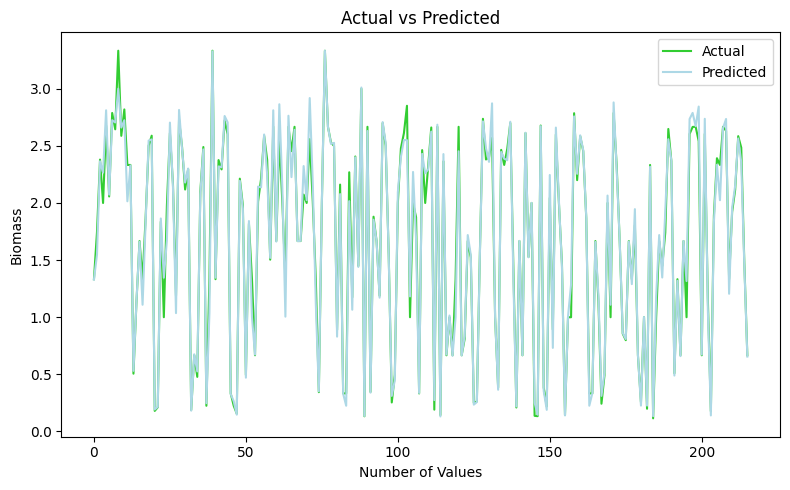

In [43]:
jeet.LinePlotAfterPrediction(y_test,y_predict)

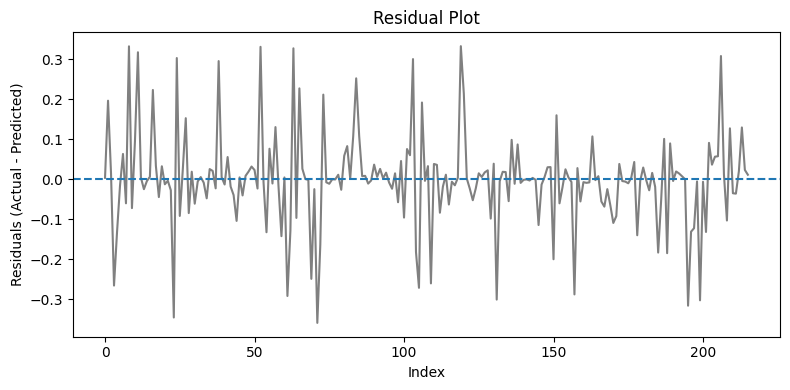

In [44]:
jeet.PredictionPlotResidual(y_test,y_predict)

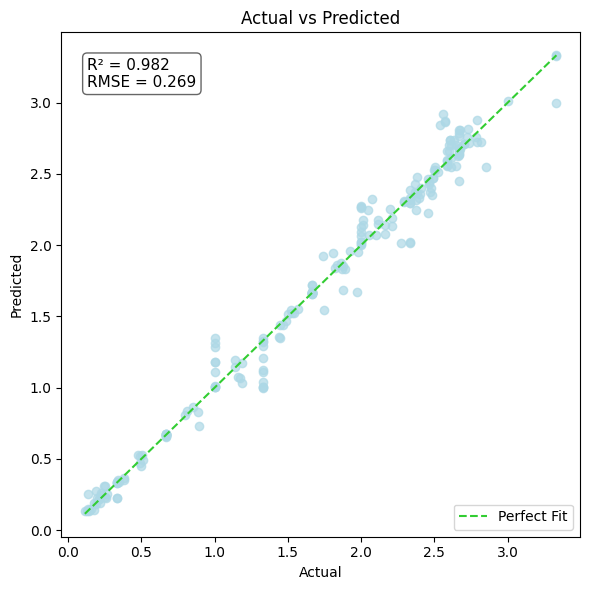

In [45]:
jeet.ScatterPlotAfterPrediction(y_test,y_predict)